# Copernicus ERA5 Reanalysis via CDS

**Last updated:** 2026-05-09

---

## Learning objectives

1. Set up `cdsapi` credentials and access the Copernicus Climate Data Store (CDS)
2. Download ERA5 surface and pressure-level data for a custom region and time period
3. Open GRIB data with `earthkit.data` — same workflow as ECMWF Open Data
4. Compute a simple climatological baseline for Africa (2m temperature)
5. Understand when to use ERA5 vs real-time Open Data

---

## Introduction

**ERA5** is ECMWF's fifth-generation atmospheric reanalysis, covering **1940 to present** at 0.25°.  
It is available free of charge via the **Copernicus Climate Data Store (CDS)**.

ERA5 is the foundation for:
- Impact model training and validation (IbF, flood, drought)
- Climate baselines and anomaly detection
- Initialisation of regional/climate models

> **Credentials:** A free CDS account is required.  
> Register at [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu), then set your personal token in `~/.cdsapirc`:  
> ```
> url: https://cds.climate.copernicus.eu/api
> key: <YOUR-PERSONAL-ACCESS-TOKEN>
> ```

**Prerequisites:** `cdsapi`, `earthkit-data[cds]`, `earthkit-plots`, `xarray`  
**Run time:** ~10 minutes (downloads ~20 MB)  
**Data:** ERA5 — 1 month, Africa bounding box


## 1) Setup & credentials


In [1]:
import cdsapi
import earthkit.data as ekd
import earthkit.plots as ekp
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from _utils import get_data_dir
DATA_DIR = get_data_dir()

# Test CDS connection
c = cdsapi.Client(quiet=True)
print('CDS client ready')
print('Data cache:', DATA_DIR)


CDS client ready
Data cache: /Users/valtze/ecmwf-open-data-guide/book/data


## 2) Download ERA5 — 2m temperature over Africa

We download one month of daily-mean 2m temperature for sub-Saharan Africa.  
This is the kind of data used for **heatwave early warning** climatologies.

Two access patterns shown:
- **`cdsapi` directly** — the traditional approach
- **`earthkit.data` wrapper** — consistent with other notebooks in this series


In [2]:
# Option A: cdsapi directly
era5_path = DATA_DIR / 'era5_africa_2t_2024_jan.grib'

if not era5_path.exists():
    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'variable': ['2m_temperature', 'total_precipitation', 'mean_sea_level_pressure'],
            'year': '2024',
            'month': '01',
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': '12:00',
            'area': [40, -20, -40, 55],  # N, W, S, E — sub-Saharan Africa
            'data_format': 'grib',
        },
        str(era5_path)
    )
    print('Downloaded:', era5_path)
else:
    print('Using cached file:', era5_path)


cd109ca4257c810132533e26fda439d1.grib:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

Downloaded: /Users/valtze/ecmwf-open-data-guide/book/data/era5_africa_2t_2024_jan.grib


In [3]:
# Option B: earthkit.data wrapper (same result, consistent API)
# Uncomment to use instead of Option A above
# ds_era5 = ekd.from_source(
#     'cds',
#     'reanalysis-era5-single-levels',
#     {
#         'product_type': 'reanalysis',
#         'variable': '2m_temperature',
#         'year': '2024', 'month': '01', 'day': '15', 'time': '12:00',
#         'area': [40, -20, -40, 55],
#         'data_format': 'grib',
#     }
# )
# print(ds_era5.ls())


## 3) Open and inspect with earthkit.data


In [4]:
ds = ekd.from_source('file', str(era5_path))
print(ds.ls())


   centre shortName typeOfLevel  level  dataDate  dataTime stepRange dataType  \
0    ecmf        2t     surface      0  20240101      1200         0       an   
1    ecmf        tp     surface      0  20240101       600       5-6       fc   
2    ecmf       msl     surface      0  20240101      1200         0       an   
3    ecmf        2t     surface      0  20240102      1200         0       an   
4    ecmf        tp     surface      0  20240102       600       5-6       fc   
..    ...       ...         ...    ...       ...       ...       ...      ...   
88   ecmf        tp     surface      0  20240130       600       5-6       fc   
89   ecmf       msl     surface      0  20240130      1200         0       an   
90   ecmf        2t     surface      0  20240131      1200         0       an   
91   ecmf        tp     surface      0  20240131       600       5-6       fc   
92   ecmf       msl     surface      0  20240131      1200         0       an   

    number    gridType  
0 

## 4) Plot — 2m temperature, Africa


/Users/valtze/miniforge3/envs/ecmwf-open-data-guide/lib/python3.10/site-packages/earthkit/plots/components/subplots.py:678: UserWarning: `plot` is deprecated. Use `quickplot` instead.
  warnings.warn("`plot` is deprecated. Use `quickplot` instead.")


Text(0.5, 1.0, 'ERA5 2m Temperature — Africa (Jan 2024)')

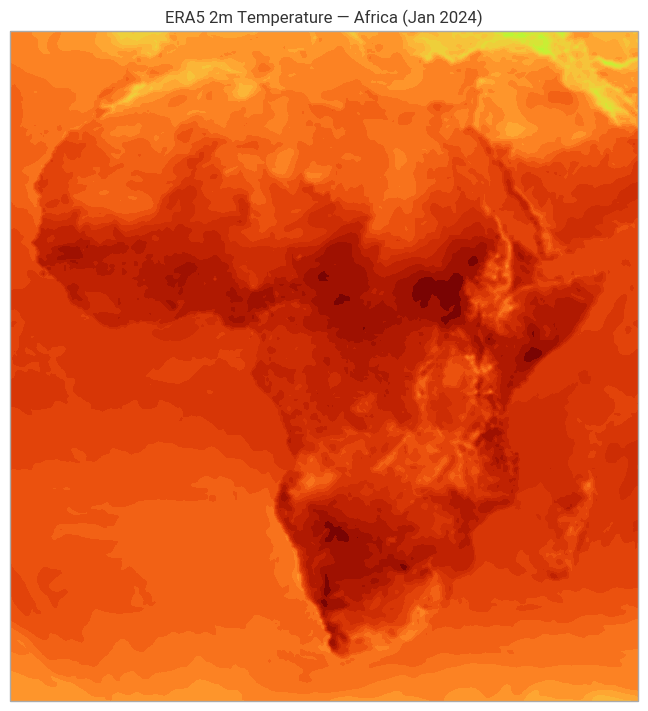

In [5]:
# Select a single 2t field and plot with earthkit.plots
t2m_fields = ds.sel(shortName='2t')
t2m_first = t2m_fields[0]

m = ekp.Map()
m.plot(t2m_first)
m.title(f"ERA5 2m Temperature — Africa (Jan 2024)")


## 5) ERA5 vs real-time Open Data — when to use which

| | ERA5 | ECMWF Open Data |
|---|---|---|
| Time coverage | 1940–present | Last ~4 days |
| Latency | ~5 days lag | ~1–6 hours |
| Grid | 0.25° | 0.25° (9km later 2026) |
| Credentials | CDS free account | None |
| Use case | Climatology, model training | Operational forecasting |

For **IbF model training**: ERA5 provides the historical climate baseline.  
For **operational triggers**: use ECMWF Open Data or SOFF forecasts.


## Take-home messages

- ERA5 is free via CDS — `cdsapi` or `earthkit.data` wrapper, same data
- The earthkit API is consistent: `ekd.from_source('cds', ...)` reads CDS data just like `ekd.from_source('file', ...)`
- Africa bounding box: `area=[40, -20, -40, 55]` (N, W, S, E)
- Next: **B02** for seasonal forecasts, **B03** for CAMS dust
